In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# For averaged files, the ecol/chicol should usually be -1 and the kcol should usually be 1.

# Takes xmu files and transforms them into dataframes whose columns are energy and mu (espace) or k and chi (kspace)

def load_spec_espace(filename, ecol=3):
    data = np.loadtxt(filename, comments = "#").T
    data = np.asarray([data[1], data[ecol]])
    data = np.transpose(data)
    data = pd.DataFrame(data)
    return data

def load_spec_kspace(filename, kcol=2, chicol=5):
    data = np.loadtxt(filename, comments = "#").T
    data = np.asarray([data[kcol], data[chicol]])
    data = np.transpose(data)
    data = pd.DataFrame(data)
    return data

In [4]:
# Grabs the index of a specific file in the list of filenames; corresponds to its index in the list of dataframes. Use this to plot.

def get_index(list, material, absorber, spectype, subdirectory = ''):
    filename = 'feff_outputs/' + subdirectory + 'xmu_' + material + '_' + absorber + '_' + spectype + '.dat'
    ix = list.index(filename)
    return ix

In [5]:
# Takes a selection of xmu files from the full library and makes two lists, one of the filepaths (to use in the get_index function) and one of the dataframes

def select_xmu(element):
    dats = []
    for file in os.listdir('feff_outputs/'):
        if 'xmu' in file:
            if element in file:
                dats.append('feff_outputs/'+file)

    for file in os.listdir('feff_outputs/averaged_outputs'):
        if 'xmu' in file:
            if element in file:
                dats.append('feff_outputs/averaged_outputs/'+file)

    xanes = []
    xes = []
    exafs = []
    for file in dats:
        if 'xanes' in file:
            xanes.append(file)
        if 'xes' in file:
            xes.append(file)
        if 'exafs' in file:
            exafs.append(file)

    xanes_df = []
    xes_df = []
    exafs_k_df = []
    for file in xanes:
        if 'averaged_outputs' in file:
            df = load_spec_espace(file, -1)
        else:
            df = load_spec_espace(file)
        xanes_df.append(df)
    for file in xes:
        if 'averaged_outputs' in file:
            df = load_spec_espace(file, -1)
        else:
            df = load_spec_espace(file)
        xes_df.append(df)
    for file in exafs:
        if 'averaged_outputs' in file:
            df = load_spec_kspace(file, 1, -1)
        else:
            df = load_spec_kspace(file)
        exafs_k_df.append(df)
    
    return xanes, xes, exafs, xanes_df, xes_df, exafs_k_df

In [6]:
xanes, xes, exafs, xanes_df, xes_df, exafs_k_df = select_xmu('Mn')

In [89]:
xanes

['feff_outputs/xmu_Mn5O8_Mn2_xanes.dat',
 'feff_outputs/xmu_MnO_Mn_xanes.dat',
 'feff_outputs/xmu_Mn3O4_Mn4_xanes.dat',
 'feff_outputs/xmu_Mn2O3_Mn8_xanes.dat',
 'feff_outputs/xmu_Mn3O4_Mn0_xanes.dat',
 'feff_outputs/xmu_MnO4_tetrahedral_xanes.dat',
 'feff_outputs/xmu_Mn2O7_Mn4_xanes.dat',
 'feff_outputs/xmu_Mn5O8_Mn0_xanes.dat',
 'feff_outputs/xmu_Mn2O7_Mn8_xanes.dat',
 'feff_outputs/xmu_Mn7O12_Mn8_xanes.dat',
 'feff_outputs/xmu_MnO2_Mn2_xanes.dat',
 'feff_outputs/xmu_Mn7O12_Mn0_xanes.dat',
 'feff_outputs/xmu_Mn2O7_Mn12_xanes.dat',
 'feff_outputs/xmu_Mn5O8_Mn8_xanes.dat',
 'feff_outputs/xmu_MnO6_octahedral_xanes.dat',
 'feff_outputs/xmu_Mn2O3_Mn0_xanes.dat',
 'feff_outputs/xmu_Mn2O7_Mn0_xanes.dat',
 'feff_outputs/xmu_MnO2_Mn0_xanes.dat',
 'feff_outputs/averaged_outputs/xmu_MnO2_Mn_xanes.dat',
 'feff_outputs/averaged_outputs/xmu_Mn2O7_Mn_xanes.dat']

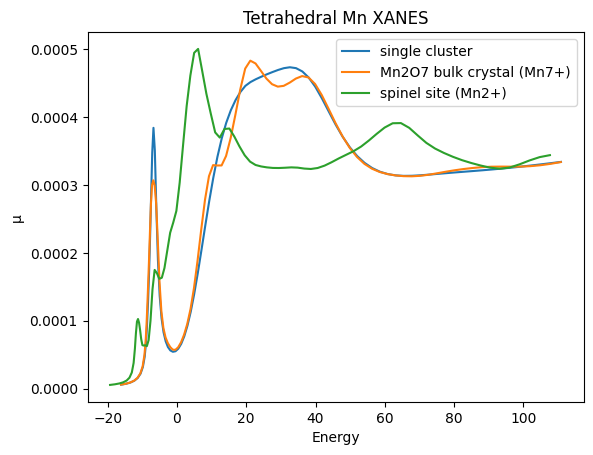

In [ ]:
i1 = get_index(xanes, 'MnO4', 'tetrahedral', 'xanes')
i2 = get_index(xanes, 'Mn2O7', 'Mn', 'xanes', 'averaged_outputs/')
i3 = get_index(xanes, 'Mn3O4', 'Mn0', 'xanes')

plt.plot(xanes_df[i1][0], xanes_df[i1][1], label = 'single cluster')
plt.plot(xanes_df[i2][0], xanes_df[i2][1], label = 'Mn2O7 bulk crystal (Mn7+)')
plt.plot(xanes_df[i3][0], xanes_df[i3][1], label = 'spinel site (Mn2+)')
plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Tetrahedral Mn XANES')
plt.legend()
plt.show()

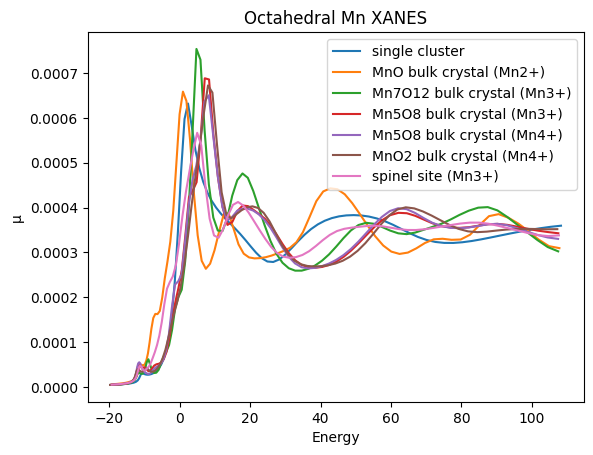

In [91]:
i2 = get_index(xanes, 'Mn5O8', 'Mn2', 'xanes')
i3 = get_index(xanes, 'Mn5O8', 'Mn8', 'xanes')
i4 = get_index(xanes, 'MnO', 'Mn', 'xanes')
i5 = get_index(xanes, 'Mn7O12', 'Mn0', 'xanes')
i6 = get_index(xanes, 'Mn3O4', 'Mn4', 'xanes')
i7 = get_index(xanes, 'MnO6', 'octahedral', 'xanes')
i8 = get_index(xanes, 'MnO2', 'Mn', 'xanes', 'averaged_outputs/')

plt.plot(xanes_df[i7][0], xanes_df[i7][1], label = 'single cluster')
plt.plot(xanes_df[i4][0], xanes_df[i4][1], label = 'MnO bulk crystal (Mn2+)')
plt.plot(xanes_df[i5][0], xanes_df[i5][1], label = 'Mn7O12 bulk crystal (Mn3+)')
plt.plot(xanes_df[i2][0], xanes_df[i2][1], label = 'Mn5O8 bulk crystal (Mn3+)')
plt.plot(xanes_df[i3][0], xanes_df[i3][1], label = 'Mn5O8 bulk crystal (Mn4+)')
plt.plot(xanes_df[i8][0], xanes_df[i8][1], label = 'MnO2 bulk crystal (Mn4+)')
plt.plot(xanes_df[i6][0], xanes_df[i6][1], label = 'spinel site (Mn3+)')

plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Octahedral Mn XANES')
plt.legend()
plt.show()

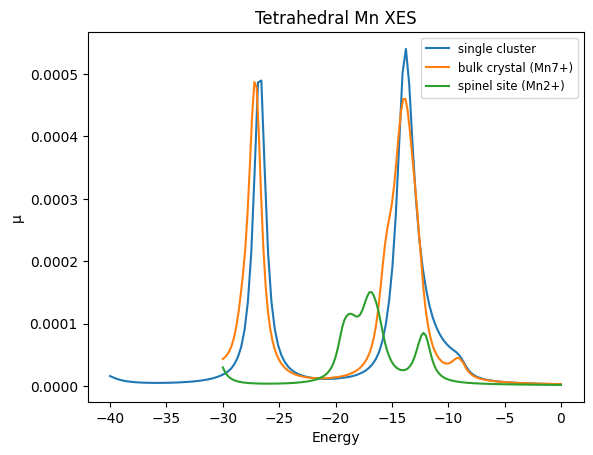

In [98]:
i1 = get_index(xes, 'MnO4', 'tetrahedral', 'xes')
i2 = get_index(xes, 'Mn2O7', 'Mn', 'xes', 'averaged_outputs/')
i3 = get_index(xes, 'Mn3O4', 'Mn0', 'xes')

plt.plot(xes_df[i1][0], xes_df[i1][1], label = 'single cluster')
plt.plot(xes_df[i2][0], xes_df[i2][1], label = 'bulk crystal (Mn7+)')
plt.plot(xes_df[i3][0], xes_df[i3][1], label = 'spinel site (Mn2+)')
plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Tetrahedral Mn XES')
plt.legend(fontsize='small')
plt.show()

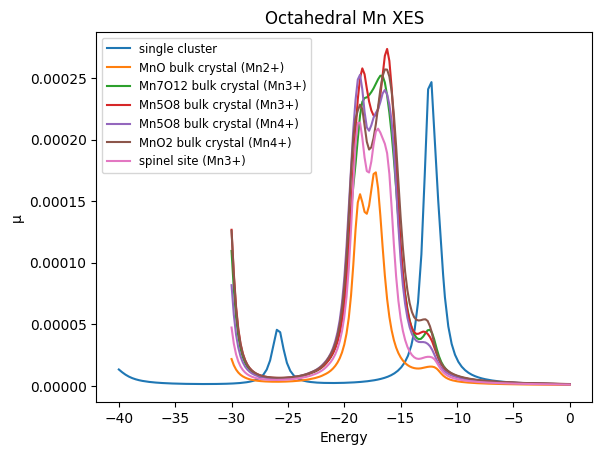

In [101]:
i1 = get_index(xes, 'Mn5O8', 'Mn2', 'xes')
i2 = get_index(xes, 'Mn5O8', 'Mn8', 'xes')
i3 = get_index(xes, 'MnO', 'Mn', 'xes')
i4 = get_index(xes, 'Mn7O12', 'Mn0', 'xes')
i5 = get_index(xes, 'Mn3O4', 'Mn4', 'xes')
i6 = get_index(xes, 'MnO6', 'octahedral', 'xes')
i7 = get_index(xes, 'MnO2', 'Mn', 'xes', 'averaged_outputs/')

plt.plot(xes_df[i6][0], xes_df[i6][1], label = 'single cluster')
plt.plot(xes_df[i3][0], xes_df[i3][1], label = 'MnO bulk crystal (Mn2+)')
plt.plot(xes_df[i4][0], xes_df[i4][1], label = 'Mn7O12 bulk crystal (Mn3+)')
plt.plot(xes_df[i1][0], xes_df[i1][1], label = 'Mn5O8 bulk crystal (Mn3+)')
plt.plot(xes_df[i2][0], xes_df[i2][1], label = 'Mn5O8 bulk crystal (Mn4+)')
plt.plot(xes_df[i7][0], xes_df[i7][1], label = 'MnO2 bulk crystal (Mn4+)')
plt.plot(xes_df[i5][0], xes_df[i5][1], label = 'spinel site (Mn3+)')

plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Octahedral Mn XES')
plt.legend(fontsize='small')
plt.show()

In [9]:
exafs_k2_df = []
for df in exafs_k_df:
    df[2] = df[1]*df[0]**2
    exafs_k2_df.append(df)

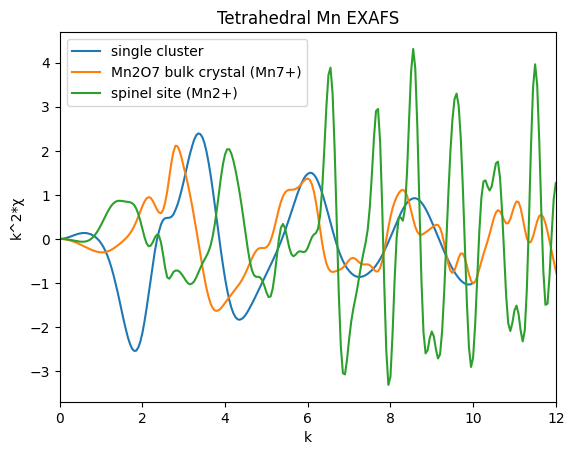

In [11]:
i1 = get_index(exafs, 'MnO4', 'tetrahedral', 'exafs')
i2 = get_index(exafs, 'Mn2O7', 'Mn', 'exafs_k', 'averaged_outputs/')
i3 = get_index(exafs, 'Mn3O4', 'Mn0', 'exafs')

plt.plot(exafs_k2_df[i1][0], exafs_k2_df[i1][2], label = 'single cluster')
plt.plot(exafs_k2_df[i2][0], exafs_k2_df[i2][2], label = 'Mn2O7 bulk crystal (Mn7+)')
plt.plot(exafs_k2_df[i3][0], exafs_k2_df[i3][2], label = 'spinel site (Mn2+)')
plt.xlim(0,12)
plt.xlabel('k')
plt.ylabel('k^2*χ')
plt.title('Tetrahedral Mn EXAFS')
plt.legend()
plt.show()

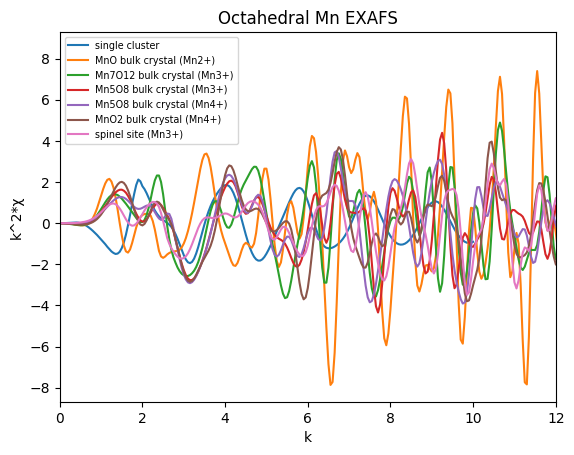

In [16]:
i1 = get_index(exafs, 'Mn5O8', 'Mn2', 'exafs')
i2 = get_index(exafs, 'Mn5O8', 'Mn8', 'exafs')
i3 = get_index(exafs, 'MnO', 'Mn', 'exafs')
i4 = get_index(exafs, 'Mn7O12', 'Mn0', 'exafs')
i5 = get_index(exafs, 'Mn3O4', 'Mn4', 'exafs')
i6 = get_index(exafs, 'MnO6', 'octahedral', 'exafs')
i7 = get_index(exafs, 'MnO2', 'Mn', 'exafs_k', 'averaged_outputs/')

plt.plot(exafs_k2_df[i6][0], exafs_k2_df[i6][2], label = 'single cluster')
plt.plot(exafs_k2_df[i3][0], exafs_k2_df[i3][2], label = 'MnO bulk crystal (Mn2+)')
plt.plot(exafs_k2_df[i4][0], exafs_k2_df[i4][2], label = 'Mn7O12 bulk crystal (Mn3+)')
plt.plot(exafs_k2_df[i1][0], exafs_k2_df[i1][2], label = 'Mn5O8 bulk crystal (Mn3+)')
plt.plot(exafs_k2_df[i2][0], exafs_k2_df[i2][2], label = 'Mn5O8 bulk crystal (Mn4+)')
plt.plot(exafs_k2_df[i7][0], exafs_k2_df[i7][2], label = 'MnO2 bulk crystal (Mn4+)')
plt.plot(exafs_k2_df[i5][0], exafs_k2_df[i5][2], label = 'spinel site (Mn3+)')

plt.xlim(0,12)
plt.xlabel('k')
plt.ylabel('k^2*χ')
plt.title('Octahedral Mn EXAFS')
plt.legend(fontsize = 'x-small')
plt.show()

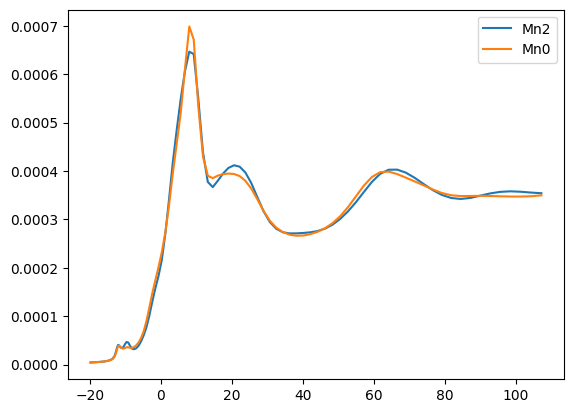

In [22]:
plt.plot(xanes_df[11][0], xanes_df[11][1], label = 'Mn2')
plt.plot(xanes_df[18][0], xanes_df[18][1], label = 'Mn0')
plt.legend()
plt.show()

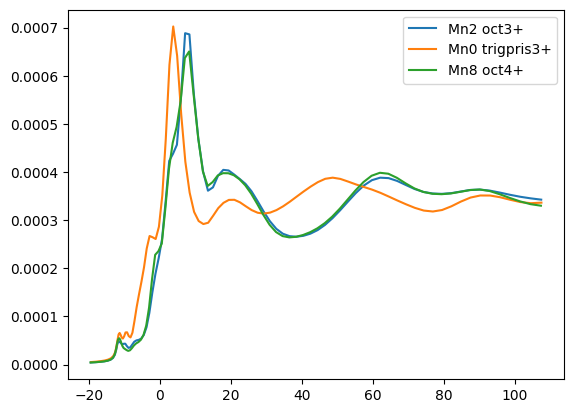

In [21]:
plt.plot(xanes_df[0][0], xanes_df[0][1], label = 'Mn2 oct3+')
plt.plot(xanes_df[7][0], xanes_df[7][1], label = 'Mn0 trigpris3+')
plt.plot(xanes_df[14][0], xanes_df[14][1], label = 'Mn8 oct4+')
plt.legend()
plt.show()

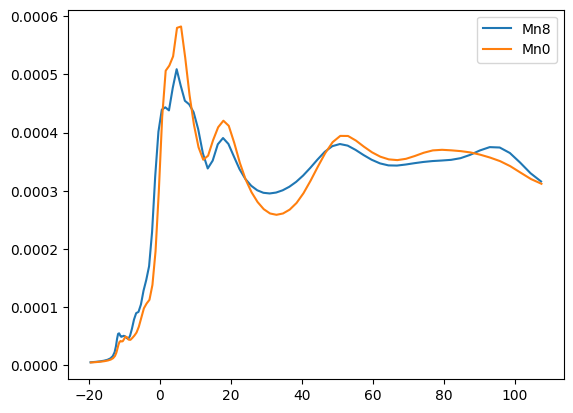

In [20]:
plt.plot(xanes_df[3][0], xanes_df[3][1], label = 'Mn8')
plt.plot(xanes_df[16][0], xanes_df[16][1], label = 'Mn0')
plt.legend()
plt.show()

In [ ]:
plt.plot(xanes_df[5][0], xanes_df[5][1], label = 'single cluster')
plt.plot(xanes_df[1][0], xanes_df[1][1], label = 'Mn2O7 bulk crystal (Mn7+)')
plt.plot(xanes_df[4][0], xanes_df[4][1], label = 'spinel site (Mn2+)')
plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Tetrahedral Mn XANES')
plt.legend()
plt.show()

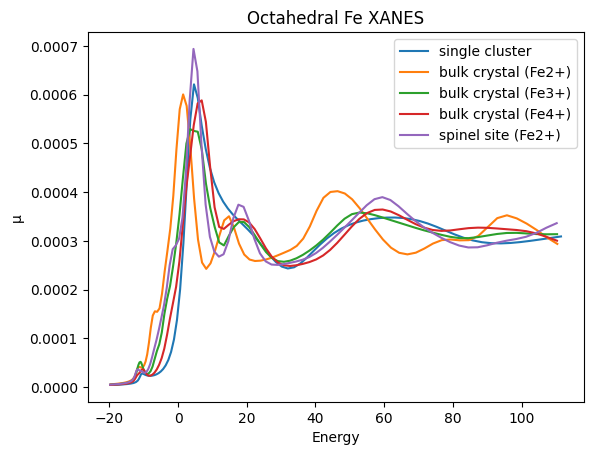

In [ ]:
plt.plot(xanes_df[15][0], xanes_df[15][1], label = 'single cluster')
plt.plot(xanes_df[7][0], xanes_df[7][1], label = 'MnO bulk crystal (Mn2+)')
plt.plot(xanes_df[6][0], xanes_df[6][1], label = 'Mn2O3 bulk crystal (Fe3+)')
plt.plot(xanes_df[2][0], xanes_df[2][1], label = 'MnO2 bulk crystal (Fe4+)')
plt.plot(xanes_df[4][0], xanes_df[4][1], label = 'spinel site (Fe2+)')
plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Octahedral Fe XANES')
plt.legend()
plt.show()

In [39]:
xes

['feff_outputs/xmu_Fe2O3_xes.dat',
 'feff_outputs/xmu_Fe3O4_Fe1_xes.dat',
 'feff_outputs/xmu_FeO_xes.dat',
 'feff_outputs/xmu_FeO6_octahedral_xes.dat',
 'feff_outputs/xmu_FeO6_trigonalprism_xes.dat',
 'feff_outputs/xmu_FeO5_squarepyramid_xes.dat',
 'feff_outputs/xmu_FeO2_xes.dat',
 'feff_outputs/xmu_Fe3O4_Fe2_xes.dat',
 'feff_outputs/xmu_FeO4_tetrahedral_xes.dat']

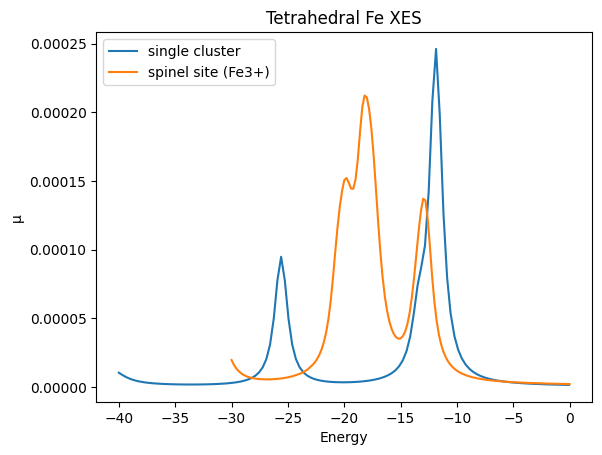

In [40]:
plt.plot(xes_df[8][0], xes_df[8][1], label = 'single cluster')
plt.plot(xes_df[7][0], xes_df[7][1], label = 'spinel site (Fe3+)')
plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Tetrahedral Fe XES')
plt.legend()
plt.show()

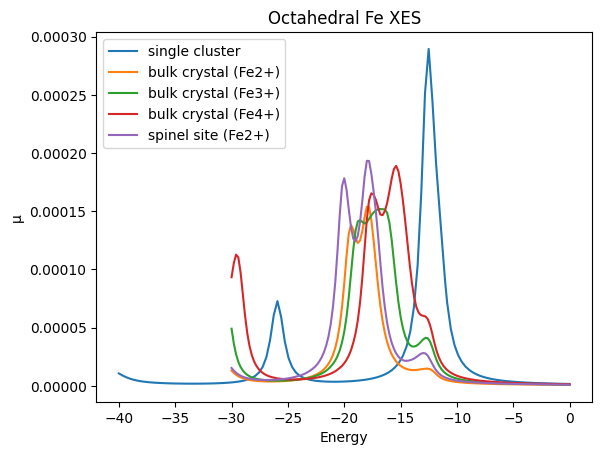

In [41]:
plt.plot(xes_df[3][0], xes_df[3][1], label = 'single cluster')
plt.plot(xes_df[2][0], xes_df[2][1], label = 'bulk crystal (Fe2+)')
plt.plot(xes_df[0][0], xes_df[0][1], label = 'bulk crystal (Fe3+)')
plt.plot(xes_df[6][0], xes_df[6][1], label = 'bulk crystal (Fe4+)')
plt.plot(xes_df[1][0], xes_df[1][1], label = 'spinel site (Fe2+)')
plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Octahedral Fe XES')
plt.legend()
plt.show()

In [42]:
exafs

['feff_outputs/xmu_Fe3O4_Fe1_exafs.dat',
 'feff_outputs/xmu_FeO5_squarepyramid_exafs.dat',
 'feff_outputs/xmu_Fe2O3_exafs.dat',
 'feff_outputs/xmu_Fe3O4_Fe2_exafs.dat',
 'feff_outputs/xmu_FeO_exafs.dat',
 'feff_outputs/xmu_FeO6_octahedral_exafs.dat',
 'feff_outputs/xmu_FeO4_tetrahedral_exafs.dat',
 'feff_outputs/xmu_FeO6_trigonalprism_exafs.dat',
 'feff_outputs/xmu_FeO2_exafs.dat']

In [43]:
#Make df of k vs k^2 chi

exafs_k2_df = []
for df in exafs_k_df:
    df[2] = df[1]*df[0]**2
    exafs_k2_df.append(df)

#print(exafs_k2_df[0])


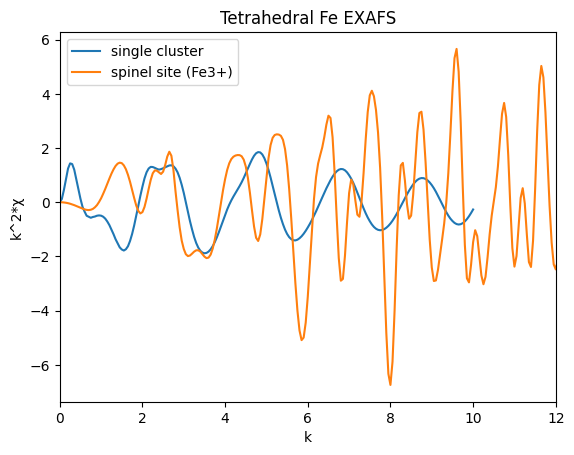

In [44]:
plt.plot(exafs_k2_df[6][0], exafs_k2_df[6][2], label = 'single cluster')
plt.plot(exafs_k2_df[3][0], exafs_k2_df[3][2], label = 'spinel site (Fe3+)')
plt.xlim(0,12)
plt.xlabel('k')
plt.ylabel('k^2*χ')
plt.title('Tetrahedral Fe EXAFS')
plt.legend()
plt.show()

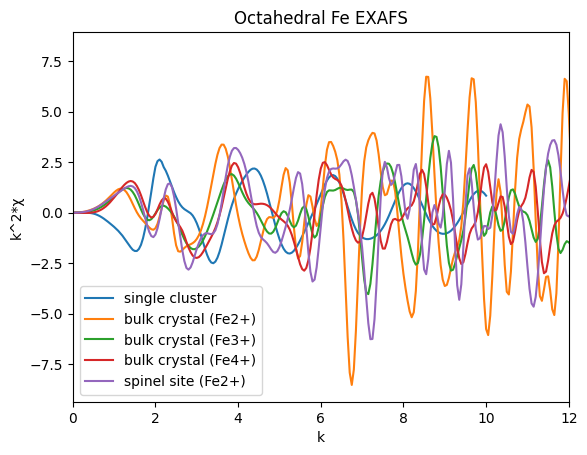

In [45]:
plt.plot(exafs_k2_df[5][0], exafs_k2_df[5][2], label = 'single cluster')
plt.plot(exafs_k2_df[4][0], exafs_k2_df[4][2], label = 'bulk crystal (Fe2+)')
plt.plot(exafs_k2_df[2][0], exafs_k2_df[2][2], label = 'bulk crystal (Fe3+)')
plt.plot(exafs_k2_df[8][0], exafs_k2_df[8][2], label = 'bulk crystal (Fe4+)')
plt.plot(exafs_k2_df[0][0], exafs_k2_df[0][2], label = 'spinel site (Fe2+)')
plt.xlim(0,12)
plt.xlabel('k')
plt.ylabel('k^2*χ')
plt.title('Octahedral Fe EXAFS')
plt.legend()
plt.show()

In [ ]:
plt.plot(exafs_k_df[0][0],exafs_k_df[0][1]+1.2, label='Mn0')
plt.plot(exafs_k_df[2][0],exafs_k_df[2][1]+0.8, label='Mn4')
plt.plot(exafs_k_df[3][0],exafs_k_df[3][1]+0.4, label='Mn8')
plt.plot(exafs_k_df[1][0],exafs_k_df[1][1], label='Mn12')
plt.xlabel('k')
plt.ylabel('χ')
plt.title('Mn2O7 EXAFS k-space stacked')
plt.legend()
plt.show()